<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana4/semana4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Aula 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

print("="*65)
print("AULA 2: OPENCV BÁSICO E PRÉ-PROCESSAMENTO INDUSTRIAL")
print("="*65)

# ==============================================================================
# 1. INGESTÃO DE DADOS
# ==============================================================================
# Simulando a captura de uma imagem
url_pecas = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png"
resposta = urllib.request.urlopen(url_pecas)
array = np.asarray(bytearray(resposta.read()), dtype=np.uint8)
img_bgr = cv2.imdecode(array, cv2.IMREAD_COLOR)

# O paradigma do OpenCV: Convertendo BGR para RGB e redimensionando
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_rgb, (600, 400))

AULA 2: OPENCV BÁSICO E PRÉ-PROCESSAMENTO INDUSTRIAL


In [9]:
# ==============================================================================
# 2. PRÉ-PROCESSAMENTO BÁSICO
# ==============================================================================
print("\n-> Iniciando limpeza de ruídos da imagem...")

# A. Convertendo para Escala de Cinza (A cor não importa para achar formatos)
img_cinza = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

# B. Gaussian Blur (Borrar levemente para sumir com micro-poeiras da lente)
img_blur = cv2.GaussianBlur(img_cinza, (1, 1), 0)

# C. Binarização (Threshold) - Tudo que for peça fica branco, o fundo fica preto
_, img_binaria = cv2.threshold(img_blur, 200, 255, cv2.THRESH_BINARY_INV)


-> Iniciando limpeza de ruídos da imagem...


In [3]:
# ==============================================================================
# 3. OPERAÇÕES MORFOLÓGICAS (Tampando buracos)
# ==============================================================================
# A binarização pode deixar falhas/buracos escuros no meio da peça iluminada.
# O "Morphological Close" dilata o branco (tampa o buraco) e depois corrói as bordas.
kernel = np.ones((5,5), np.uint8)
img_fechada = cv2.morphologyEx(img_binaria, cv2.MORPH_CLOSE, kernel, iterations=2)

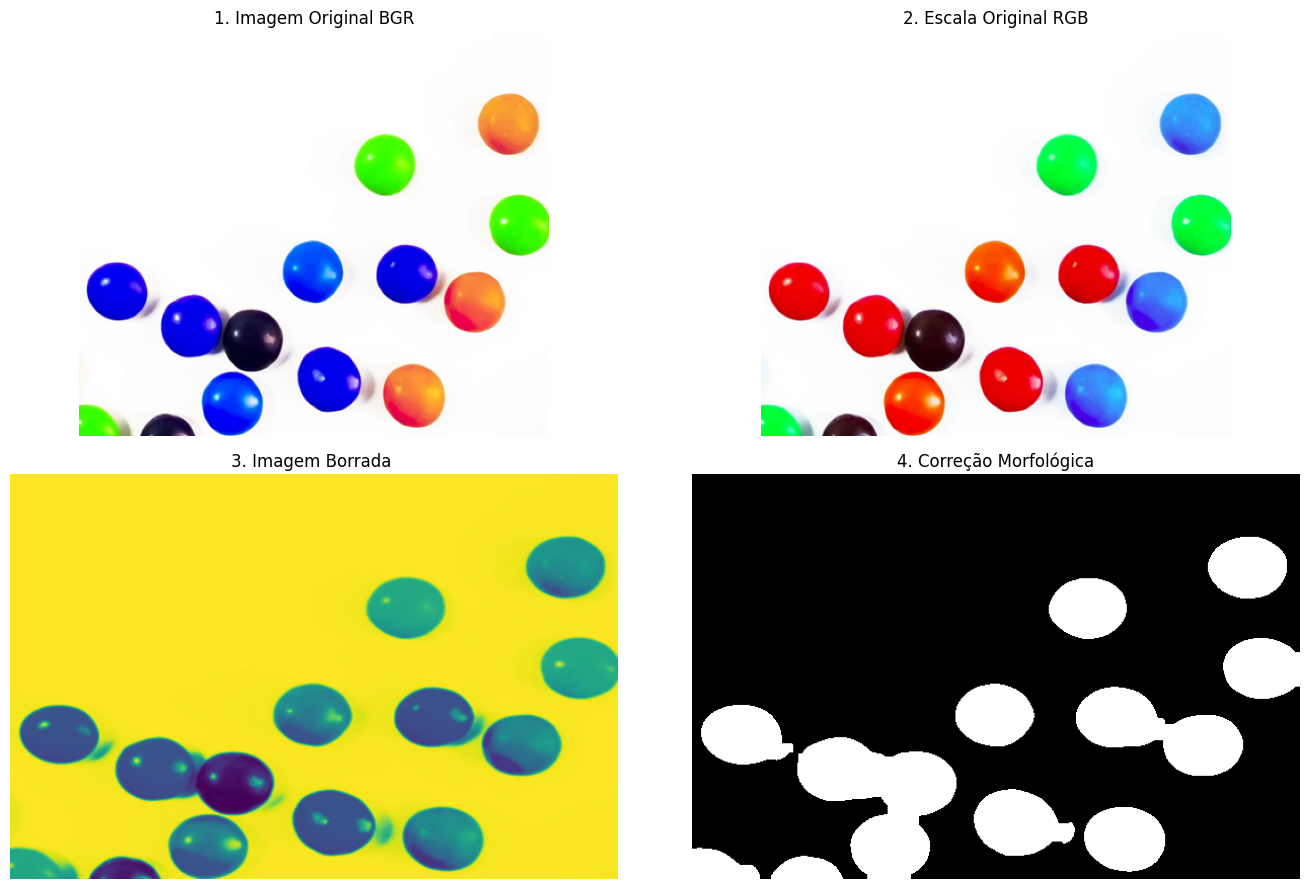


[FIM DA AULA 2] A imagem está limpa e pronta para extração de contornos!


In [8]:
# ==============================================================================
# RENDERIZAÇÃO DA AULA 2
# ==============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0, 0].imshow(img_bgr)
ax[0, 0].set_title("1. Imagem Original BGR")

ax[0, 1].imshow(img_rgb)
ax[0, 1].set_title("2. Escala Original RGB")

ax[1, 0].imshow(img_blur)
ax[1, 0].set_title("3. Imagem Borrada ")

ax[1, 1].imshow(img_fechada, cmap='gray')
ax[1, 1].set_title("4. Correção Morfológica")

for a in ax.flat:
    a.axis('off')

plt.tight_layout()
plt.show()

print("\n[FIM DA AULA 2] A imagem está limpa e pronta para extração de contornos!")

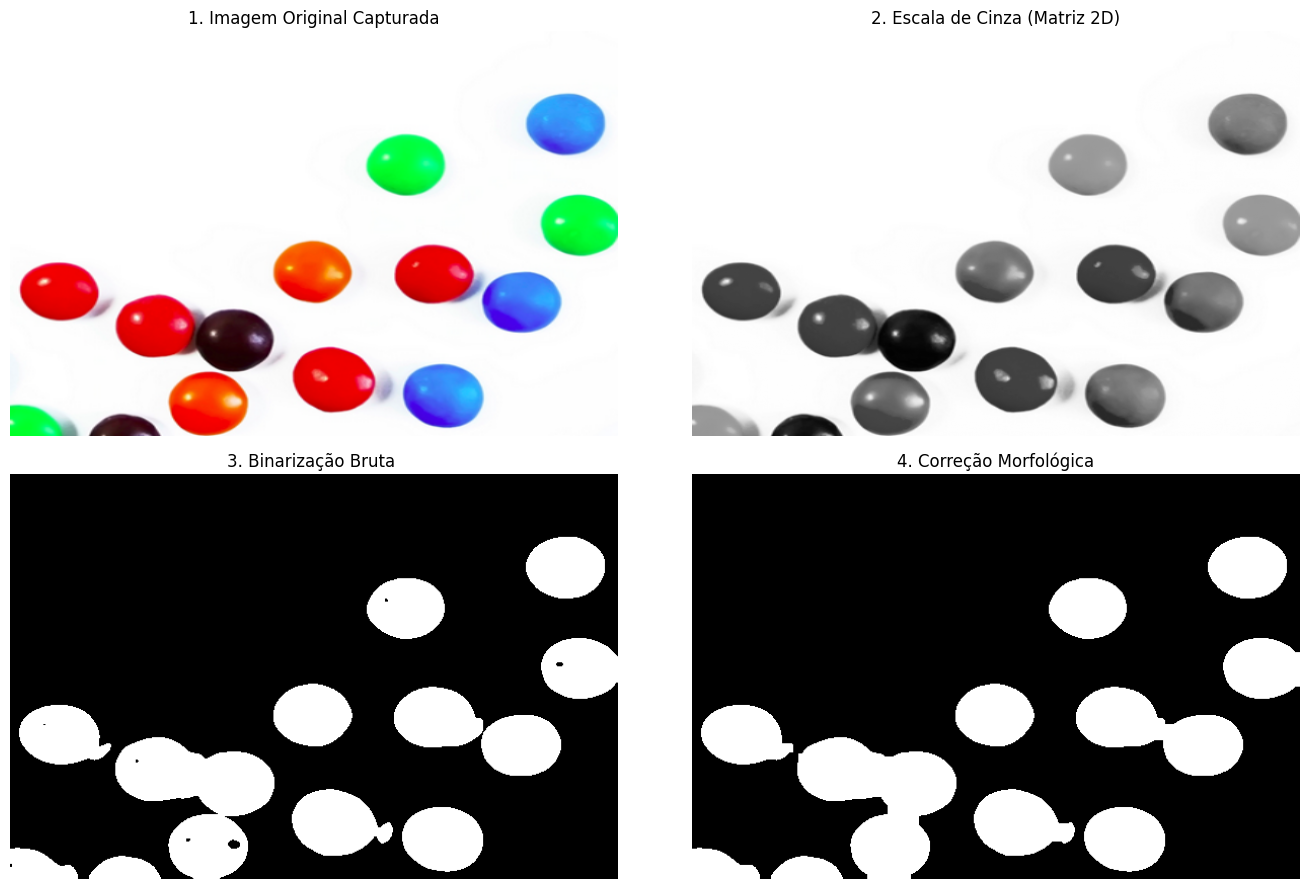


[FIM DA AULA 2] A imagem está limpa e pronta para extração de contornos!


In [5]:
# ==============================================================================
# RENDERIZAÇÃO DA AULA 2
# ==============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0, 0].imshow(img_original)
ax[0, 0].set_title("1. Imagem Original Capturada")

ax[0, 1].imshow(img_cinza, cmap='gray')
ax[0, 1].set_title("2. Escala de Cinza (Matriz 2D)")

ax[1, 0].imshow(img_binaria, cmap='gray')
ax[1, 0].set_title("3. Binarização Bruta ")

ax[1, 1].imshow(img_fechada, cmap='gray')
ax[1, 1].set_title("4. Correção Morfológica")

for a in ax.flat:
    a.axis('off')

plt.tight_layout()
plt.show()

print("\n[FIM DA AULA 2] A imagem está limpa e pronta para extração de contornos!")

In [10]:
dilated = cv2.dilate(img_rgb, np.ones((7, 7), np.uint8))
bg_img = cv2.medianBlur(dilated, 21)

# 3. Calcular a diferença absoluta e inverter (para manter fundo branco)
diff_img = 255 - cv2.absdiff(img_rgb, bg_img)

# 4. Normalizar para usar todo o intervalo dinâmico (melhorar contraste)
resultado = cv2.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

cv2.imwrite('resultado.jpg', resultado)

True

## Aula 3

In [27]:
print("\n" + "="*65)
print("AULA 3: DETECÇÃO DE BORDAS, CONTORNOS E CAIXAS (YOLO BASE)")
print("="*65)

# ==============================================================================
# 1. ALGORITMO CANNY (Extração Clássica de Bordas)
# ==============================================================================
print("\n-> Aplicando Algoritmo Canny para ver apenas os contornos finos...")
# O Canny desenha uma linha branca fina sempre que a luz muda drasticamente
img_bordas = cv2.Canny(img_cinza, 100, 200)



AULA 3: DETECÇÃO DE BORDAS, CONTORNOS E CAIXAS (YOLO BASE)

-> Aplicando Algoritmo Canny para ver apenas os contornos finos...


In [30]:
# ==============================================================================
# 2. EXTRAÇÃO E MAPEAMENTO DE CONTORNOS
# ==============================================================================
print("-> Encontrando a geometria das peças na imagem limpa da Aula 2...")
# O findContours puxa as coordenadas X e Y de cada mancha branca da imagem "img_fechada"
contornos, hierarquia = cv2.findContours(img_fechada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_resultado = img_original.copy()
pecas_validas = 0

-> Encontrando a geometria das peças na imagem limpa da Aula 2...


In [31]:
# ==============================================================================
# 3. ANÁLISE ESPACIAL E BOUNDING BOXES
# ==============================================================================
print("-> Filtrando sujeiras pela área e desenhando as Bounding Boxes...")

for contorno in contornos:
    # A. Calculando a área em pixels do objeto detectado
    area = cv2.contourArea(contorno)

    # B. Lógica de Negócio: Ignorar manchas pequenas (menos de 500 pixels)
    if area > 300:
        pecas_validas += 1

        # C. Extrair as coordenadas do Retângulo Envolvente (Bounding Box)
        x, y, largura, altura = cv2.boundingRect(contorno)

        # D. Desenhar o retângulo vermelho na foto original
        cv2.rectangle(img_resultado, (x, y), (x + largura, y + altura), (255, 0, 0), 3)

        # E. Escrever a área calculada em cima da peça
        texto = f"Area: {int(area)}"
        cv2.putText(img_resultado, texto, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

print(f"\n[SUCESSO] O sistema identificou, filtrou e isolou {pecas_validas} peças válidas!")

-> Filtrando sujeiras pela área e desenhando as Bounding Boxes...

[SUCESSO] O sistema identificou, filtrou e isolou 11 peças válidas!


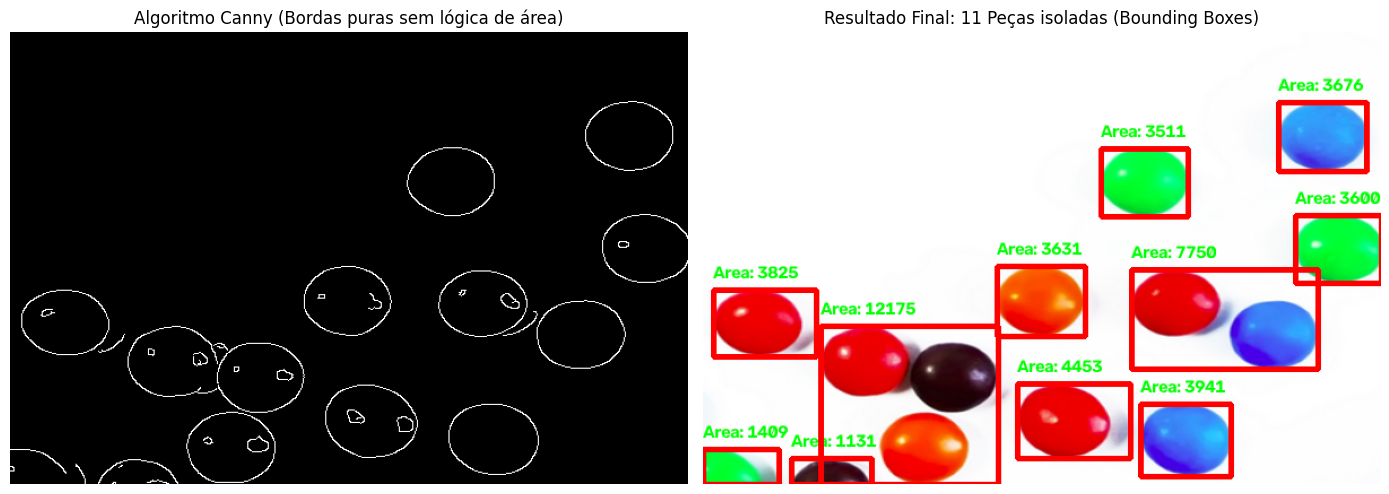

In [32]:
# ==============================================================================
# RENDERIZAÇÃO DA AULA 3
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(img_bordas, cmap='gray')
ax[0].set_title("Algoritmo Canny (Bordas puras sem lógica de área)")
ax[0].axis('off')

ax[1].imshow(img_resultado)
ax[1].set_title(f"Resultado Final: {pecas_validas} Peças isoladas (Bounding Boxes)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Testar imagens

LENDO UMA IMAGEM DA PASTA DO COLAB
-> Sucesso! A matriz da foto possui resolução: (581, 580, 3) (Altura x Largura x Canais)


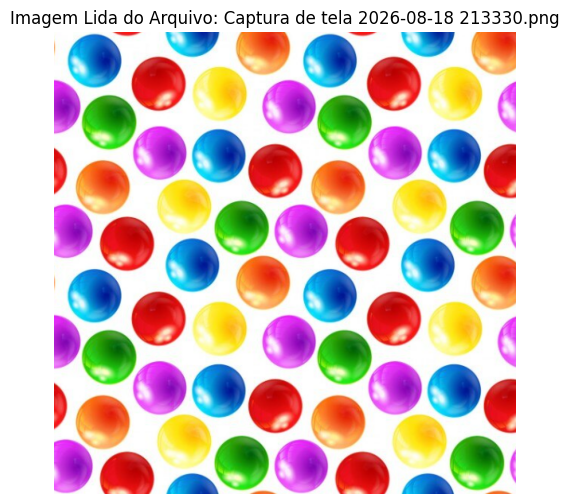

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("="*65)
print("LENDO UMA IMAGEM DA PASTA DO COLAB")
print("="*65)

# ==============================================================================
# 1. NOME DO ARQUIVO
# ==============================================================================
nome_arquivo = "Captura de tela 2026-08-18 213330.png"

# ==============================================================================
# 2. LEITURA E VERIFICAÇÃO DE ERROS
# ==============================================================================
# O OpenCV lê a imagem e guarda na matriz BGR
img_pc_bgr = cv2.imread(nome_arquivo)

# Boas práticas: Sempre verificar se o OpenCV realmente encontrou a imagem
if img_pc_bgr is None:
    print(f"\n[ERRO FATAL] O OpenCV não achou o arquivo '{nome_arquivo}'.")

else:
    # ==============================================================================
# 3. CONVERSÃO E RENDERIZAÇÃO
    # ==============================================================================
    # Convertendo para o padrão de cores humano (RGB)
    img_pc_rgb = cv2.cvtColor(img_pc_bgr, cv2.COLOR_BGR2RGB)

    print(f"-> Sucesso! A matriz da foto possui resolução: {img_pc_rgb.shape} (Altura x Largura x Canais)")

    # Exibindo a foto na tela
    plt.figure(figsize=(8, 6))
    plt.imshow(img_pc_rgb)
    plt.title(f"Imagem Lida do Arquivo: {nome_arquivo}")
    plt.axis('off')
    plt.show()

    # A partir daqui, você pode puxar essa variável 'img_pc_rgb' e aplicar o Canny, Threshold, etc!

In [48]:
img_cinza = cv2.cvtColor(img_pc_rgb, cv2.COLOR_RGB2GRAY)

# B. Gaussian Blur (Borrar levemente para sumir com micro-poeiras da lente)
img_blur = cv2.GaussianBlur(img_pc_rgb, (7, 7), 0)

# C. Binarização (Threshold) - Tudo que for peça fica branco, o fundo fica preto
#_, img_binaria = cv2.threshold(img_blur, 200, 255, cv2.THRESH_BINARY_INV)

# O Canny desenha uma linha branca fina sempre que a luz muda drasticamente
#img_bordas = cv2.Canny(img_cinza, 100, 200)

# C. Binarização (Threshold) - Tudo que for peça fica branco, o fundo fica preto
#_, img_binaria = cv2.threshold(img_blur, 200, 255, cv2.THRESH_BINARY_INV)

#kernel = np.ones((5,5), np.uint8)
#img_fechada = cv2.morphologyEx(img_binaria, cv2.MORPH_CLOSE, kernel, iterations=2)


#contornos, hierarquia = cv2.findContours(img_fechada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#img_resultado = img_original.copy()
#pecas_validas = 0

for contorno in contornos:
    # A. Calculando a área em pixels do objeto detectado
    area = cv2.contourArea(contorno)

    # B. Lógica de Negócio: Ignorar manchas pequenas (menos de 500 pixels)
    if area > 300:
        pecas_validas += 1

        # C. Extrair as coordenadas do Retângulo Envolvente (Bounding Box)
        x, y, largura, altura = cv2.boundingRect(contorno)

        # D. Desenhar o retângulo vermelho na foto original
        cv2.rectangle(img_resultado, (x, y), (x + largura, y + altura), (255, 0, 0), 3)

        # E. Escrever a área calculada em cima da peça
        texto = f"Area: {int(area)}"
        cv2.putText(img_resultado, texto, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)


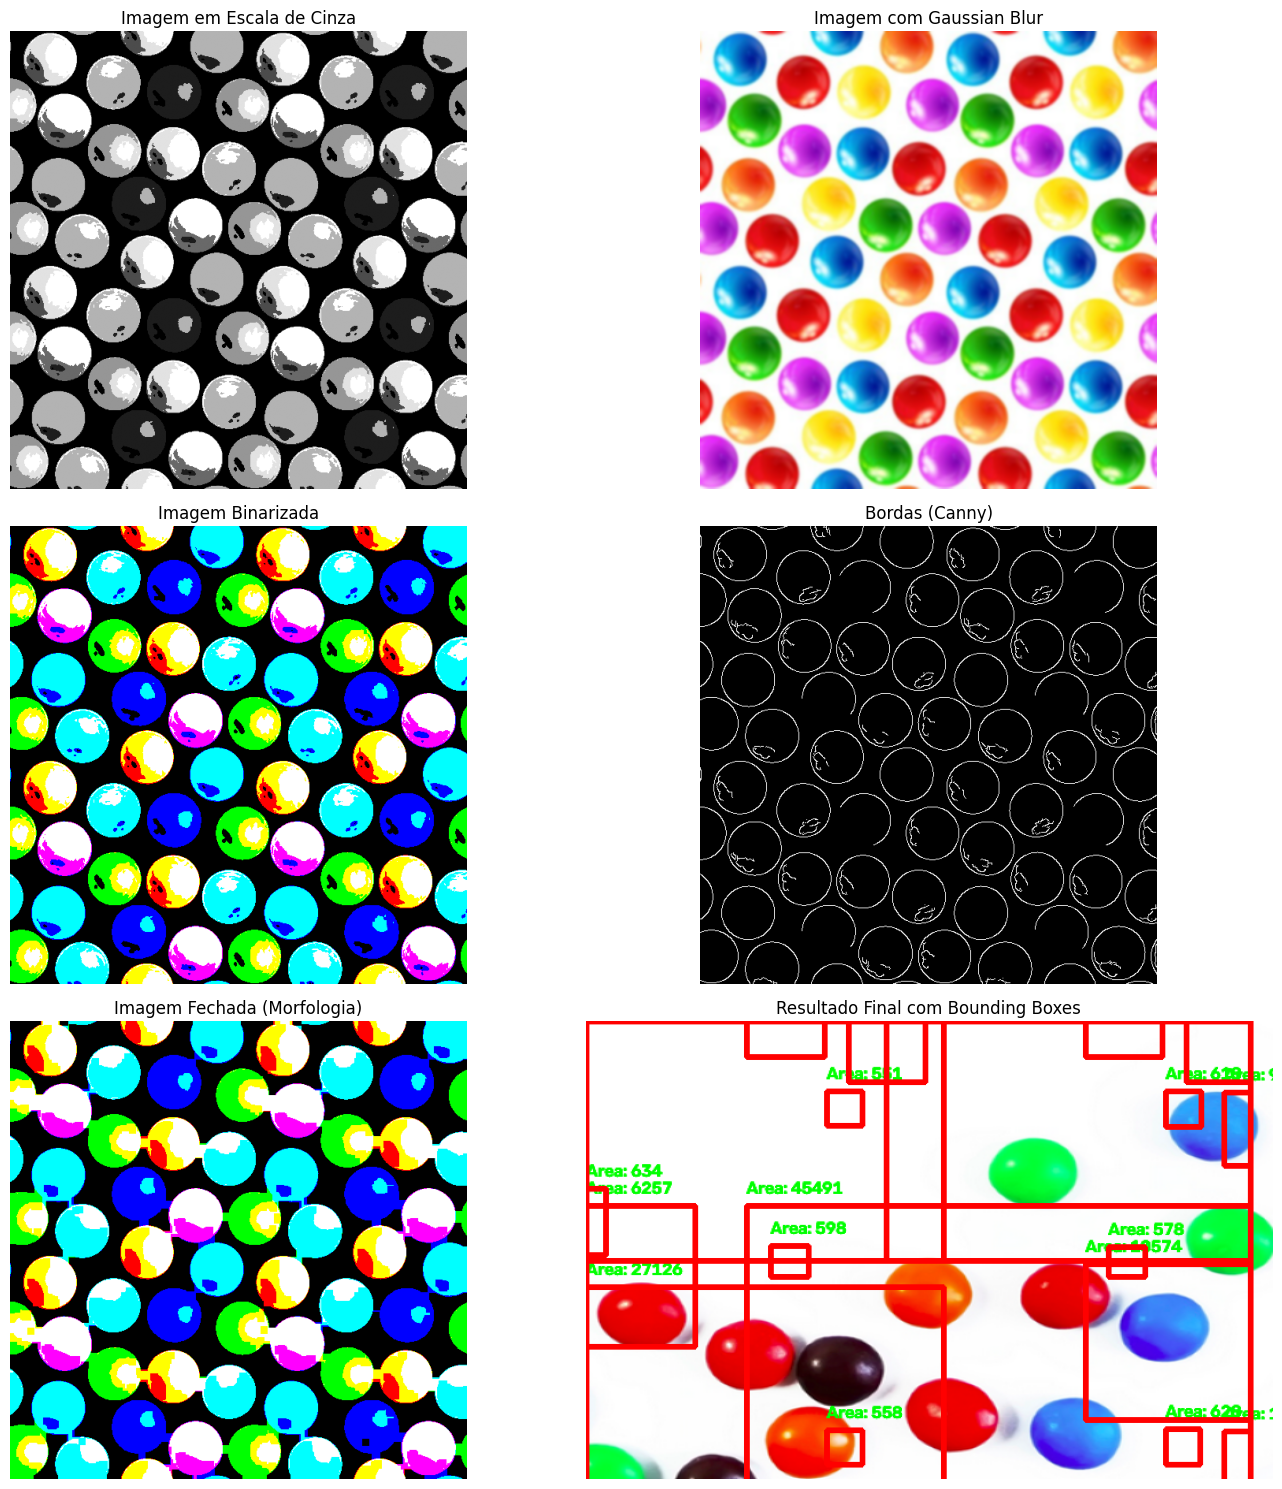

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(15, 15))

ax[0, 0].imshow(img_cinza, cmap='gray')
ax[0, 0].set_title('Imagem em Escala de Cinza')
ax[0, 0].axis('off')

ax[0, 1].imshow(img_blur, cmap='gray')
ax[0, 1].set_title('Imagem com Gaussian Blur')
ax[0, 1].axis('off')

ax[1, 0].imshow(img_binaria, cmap='gray')
ax[1, 0].set_title('Imagem Binarizada')
ax[1, 0].axis('off')

ax[1, 1].imshow(img_bordas, cmap='gray')
ax[1, 1].set_title('Bordas (Canny)')
ax[1, 1].axis('off')

ax[2, 0].imshow(img_fechada, cmap='gray')
ax[2, 0].set_title('Imagem Fechada (Morfologia)')
ax[2, 0].axis('off')

ax[2, 1].imshow(img_resultado)
ax[2, 1].set_title('Resultado Final com Bounding Boxes')
ax[2, 1].axis('off')

plt.tight_layout()
plt.show()